## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?

Regression predicts a continuous numeric value (e.g., house price). Classification predicts a discrete category (e.g., spam or not spam).

2. What is a confusion table? What does it help us understand about a model's performance?

A confusion table (or matrix) cross-tabulates predicted classes against actual classes. It shows which kinds of errors the model makes, not just how many: false positives versus false negatives, and which classes get confused with each other. From it you can compute accuracy, precision, recall, and specificity.

3. What does the SSE quantify about a particular model?

SSE is the total of the squared differences between predicted and actual values. It measures how far predictions miss overall, so lower is better. Squaring makes large errors count heavily.

4. What are overfitting and underfitting?

Overfitting: the model is too complex and memorizes noise in the training data. It does well on training data but poorly on new data (high variance). A k-NN model with k = 1 is an example.

Underfitting: the model is too simple to capture the real pattern. It does poorly on both training and new data (high bias). A k-NN model with a very large k is an example

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

Training error is a biased score, because the model has already seen that data. If you judged by training error alone, you would always pick the most complex model, such as k = 1. Evaluating each k on held-out data estimates how the model performs on unseen data. That lets you pick the k that balances overfitting and underfitting, so the model generalizes better.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Class label

Strengths: simple, easy to interpret, and ready to act on directly.
Weaknesses: it hides uncertainty, so a 51% call looks the same as a 99% call. It also fixes the decision threshold, usually at 0.5.

Probability
Strengths: it conveys confidence and lets you set your own threshold based on error costs. It also supports ranking, ROC/AUC analysis, and risk-based decisions.
Weaknesses: it is harder to communicate, and someone still has to choose a threshold to act on it. The probabilities can also be poorly calibrated, which makes them misleading if taken at face value.


**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sufyan Billel

**Date:** 10/2/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DS3001/land_mines.csv')

print(df.head())
print(df.shape)
print(df.isnull().sum())

Mounted at /content/drive
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64


mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


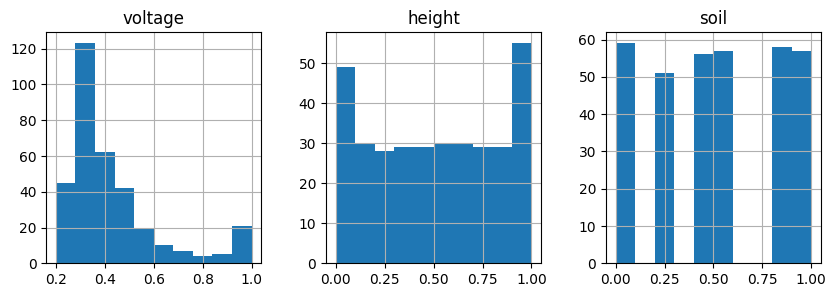

            voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923


In [ ]:
print(df['mine_type'].value_counts().sort_index())

print(df[['voltage', 'height', 'soil']].describe())

df[['voltage', 'height', 'soil']].hist(figsize=(10, 3), layout=(1, 3))
plt.show()

print(df.groupby('mine_type')[['voltage', 'height', 'soil']].mean())

In [ ]:
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y)

print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


Best k: 2
Best accuracy: 0.4378698224852071


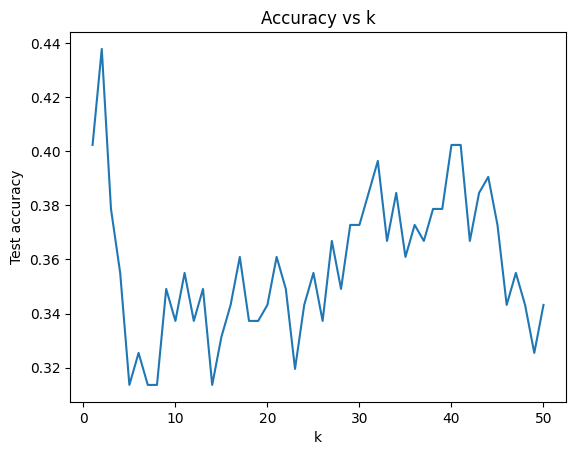

In [ ]:
k_values = range(1, 51)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    accuracies.append(acc)

best_k = k_values[accuracies.index(max(accuracies))]
print('Best k:', best_k)
print('Best accuracy:', max(accuracies))

plt.plot(k_values, accuracies)
plt.xlabel('k')
plt.ylabel('Test accuracy')
plt.title('Accuracy vs k')
plt.show()

 A smaller k had the best accuracy, with k =2 having the best test accuracy.

In [ ]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted']))
print('Accuracy:', (y_pred == y_test).mean())

for m in sorted(y_test.unique()):
    mask = y_test == m
    print('Mine type', m, 'accuracy:', round((y_pred[mask] == m).mean(), 2))

Predicted   1   2   3  4  5
Actual                     
1          25   0   6  4  1
2           0  32   0  3  0
3          12   2   9  6  4
4          12   5   8  8  0
5          15   2  10  5  0
Accuracy: 0.4378698224852071
Mine type 1 accuracy: 0.69
Mine type 2 accuracy: 0.91
Mine type 3 accuracy: 0.27
Mine type 4 accuracy: 0.24
Mine type 5 accuracy: 0.0


Q1.4 Mine type 2 is predicted very well, at 91%. It is almost never confused with other types, and when the model predicts type 2 it's right about 78% of the time.
Mine type 1 is also predicted fairly well, at 69%.
Types 3, 4, and 5 are predicted poorly: 27%, 24%, and 0%. The model never correctly identifies type 5. These three types are mostly confused with each other and with type 1, which suggests their voltage, height, and soil values overlap heavily.
Type 1 is over-predicted. The model labels 64 cases as type 1, but only 25 of them actually are. Thirty-nine mines of types 3, 4, and 5 were misclassified as type 1. So a high 69% accuracy for type 1 doesn't mean a type 1 prediction is reliable; it's correct only about 39% of the time.

Q1.5 I'd advise not to treat the prediction as certain. Use the model as a screening or prioritization tool, not as a final decision as seen by its confusion and inaccuracy for certain mine types. Every site should still be handled as if a mine could be present.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Avoid an even k (the main bug). With k = 2, many predictions are 1-vs-1 ties. When the vote ties, sklearn picks the lowest class label. That alone pushes predictions toward type 1 and away from type 5, which fits your results: type 1 is over-predicted 64 times, and type 5 is correctly identified 0 times. Search odd k only (range(1, 51, 2)), or use weights='distance', which rarely ties.
2. Choose k with cross-validation on the training set, not the test set. You picked k by test accuracy and then reported test accuracy for that same k, so 0.438 is optimistically biased. Your accuracy curve is also very jagged, which means the best k depends heavily on this particular split. Use GridSearchCV(..., cv=5) on X_train and keep the test set for the final evaluation only. The assignment text allows test-set selection, so if you keep it, at least say the reported accuracy is optimistic.
3. Treat soil as categorical. Soil takes 6 discrete values (0, 0.2, …, 1.0). In the original dataset these are soil types (e.g., dry/humid × sandy/humus/limy), so the numeric distance between 0.2 and 0.8 is arbitrary. One-hot encode it, or at least note the issue. Check the codebook to confirm.
4. Put scaling in a pipeline. The features are already roughly on [0, 1], so the effect may be small. A Pipeline with MinMaxScaler makes the model robust to that assumption and avoids leakage during cross-validation.
5. Replace the hand-written per-class loop with sklearn metrics. classification_report(y_test, y_pred) gives you recall (what your loop computes), precision (what you calculated by hand for type 1), and F1 in one call. ConfusionMatrixDisplay gives a cleaner table.
6. Strengthen the EDA. Your groupby means already show the key fact: voltage separates type 2 (0.72 vs. ~0.3–0.4), while height and soil barely differ across types. Add boxplots of each feature by mine_type and state this explicitly. It explains why type 2 is easy and types 3–5 overlap.
7. Fix the labels and fill in the explanations. Your markdown cells say "Q1.4"/"Q1.5" but should say Q2.4/Q2.5. Q2.3 asks you to explain how you selected k, and right now that's one sentence.
8. Make the Q2.5 advice concrete. Use predict_proba and flag low-confidence predictions. Treat a "type 1" prediction as unreliable, since it's right only 39% of the time. Trust "type 2" more. Weigh the asymmetric cost of mistaking a dangerous type for a less dangerous one. Never use the prediction to skip safe-removal procedures. More discriminating features (better sensors) are the real fix.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept| Helps stop bias|
| 2 | Reject | While using the test set leads to some bias, I don't think it's necessary to switch, since it'll still work well |
| 3 | Accept | Makes sense to change it to categorical |
| 4 | Reject| Not necessary since the features are already on [0,1] |
| 5 | Accept| Cleaner table |
| 6 | Accept | Easier to see reasoning behind groupby |
| 7 | Accept | Labels need to be fixed |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/DS3001/land_mines.csv')
print(df.head())
print(df.shape)
print(df.isnull().sum())

In [ ]:
features = ['voltage', 'height', 'soil']

print(df['mine_type'].value_counts().sort_index())
print(df[features].describe())
print(df.groupby('mine_type')[features].mean())

# How each feature varies by mine type
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, features):
    df.boxplot(column=col, by='mine_type', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('mine_type')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Soil is a categorical code with 6 levels
print(pd.crosstab(df['soil'].round(1), df['mine_type']))

In [ ]:
soil_dummies = pd.get_dummies(df['soil'].round(1), prefix='soil', dtype=int)
X = pd.concat([df[['voltage', 'height']], soil_dummies], axis=1)
y = df['mine_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y)

print(X.columns.tolist())
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

In [ ]:
k_values = list(range(1, 51, 2))   # odd k avoids 1-vs-1 vote ties
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracies.append(model.score(X_test, y_test))

best_k = k_values[int(np.argmax(accuracies))]
print('Best k:', best_k)
print('Best test accuracy:', round(max(accuracies), 3))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k (odd values)')
plt.ylabel('Test accuracy')
plt.title('Test accuracy vs k')
plt.show()

In [ ]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title(f'Confusion matrix, k = {best_k}')
plt.show()

# recall = share of each actual type identified correctly
# precision = how often a prediction of that type is right
print(classification_report(y_test, y_pred, digits=2))

In [ ]:
proba = model.predict_proba(X_test)
confidence = proba.max(axis=1)
correct = y_pred == y_test.to_numpy()

summary = pd.DataFrame({'confidence': confidence, 'correct': correct})
print(summary.groupby(pd.cut(confidence, [0, 0.5, 0.75, 1.0]), observed=False)['correct']
      .agg(['count', 'mean']))